# Campos Dirigidos
# Laboratorio 10
# Grafo 2

In [6]:
#importar las librerías
#librería utilizada para graficar
import networkx as nx
#librería que me permite trabajar con estructuras complejas, como Grafos
import matplotlib.pyplot as plt

In [11]:
# Creamos el grafo

grafo = nx.DiGraph()

grafo.add_weighted_edges_from([
    ("Norte", "Este", 8),
    ("Este", "Aeropuerto", 20),
    ("Oeste", "Aeropuerto", 18),
    ("Centro", "Norte", 10),
    ("Norte", "Sur", 30),
    ("Centro", "Sur", 15),
    ("Centro", "Este", 25),
    ("Norte", "Oeste", 15),
    ("Sur", "Oeste", 9)
])

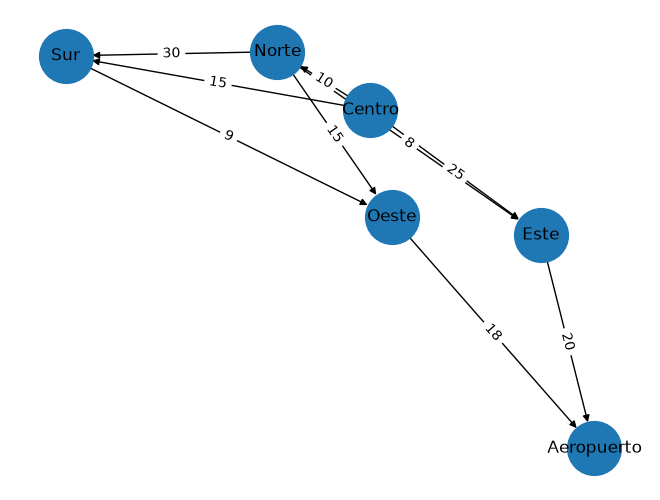

In [12]:
# Imprimimos el grafo
pos = nx.spring_layout(grafo, seed=10)

nx.draw(
    grafo,
    pos,
    with_labels=True,
    node_size=1500,
    arrows=True
)

labels = nx.get_edge_attributes(grafo, "weight")

nx.draw_networkx_edge_labels(
    grafo,
    pos,
    edge_labels=labels
)

plt.show()

In [13]:
# Mostramos las rutas

rutas = list(
    nx.all_simple_paths(
        grafo,
        source="Centro",
        target="Aeropuerto"
    )
)

# Imprimimos las rutas
for i, ruta in enumerate(rutas, start=1):
    print(f"Ruta {i}: {ruta}")

Ruta 1: ['Centro', 'Norte', 'Este', 'Aeropuerto']
Ruta 2: ['Centro', 'Norte', 'Sur', 'Oeste', 'Aeropuerto']
Ruta 3: ['Centro', 'Norte', 'Oeste', 'Aeropuerto']
Ruta 4: ['Centro', 'Sur', 'Oeste', 'Aeropuerto']
Ruta 5: ['Centro', 'Este', 'Aeropuerto']


In [14]:
# Calculamos el costo
def costo_ruta(grafo, ruta):
    costo = 0
    for i in range(len(ruta) - 1):
        costo += grafo[ruta[i]][ruta[i + 1]]["weight"]
    return costo

# Imprimimos el costo
for i, ruta in enumerate(rutas, start=1):
    costo = costo_ruta(grafo, ruta)
    print(f"Ruta {i}: {ruta} -> {costo} unidades")

Ruta 1: ['Centro', 'Norte', 'Este', 'Aeropuerto'] -> 38 unidades
Ruta 2: ['Centro', 'Norte', 'Sur', 'Oeste', 'Aeropuerto'] -> 67 unidades
Ruta 3: ['Centro', 'Norte', 'Oeste', 'Aeropuerto'] -> 43 unidades
Ruta 4: ['Centro', 'Sur', 'Oeste', 'Aeropuerto'] -> 42 unidades
Ruta 5: ['Centro', 'Este', 'Aeropuerto'] -> 45 unidades


In [17]:
# Utilizamos algoritmo para obtener la ruta más corta

ruta_mas_corta = nx.dijkstra_path(grafo, source="Centro", target="Aeropuerto", weight='weight')

tiempo_total = nx.dijkstra_path_length(grafo, source="Centro", target="Aeropuerto", weight="weight")

In [18]:
# Imprimir

print(f"La ruta mas corta es: {ruta_mas_corta}")
print(f"El tiempo total es: {tiempo_total} minutos")

La ruta mas corta es: ['Centro', 'Norte', 'Este', 'Aeropuerto']
El tiempo total es: 38 minutos
